## Section 0 — Imports and Constants

This section establishes all package dependencies and fixed experimental constants used throughout the notebook. Defining constants in one location ensures reproducibility and enforces the professor-imposed constraint that only out-of-band bins are used for classification.

In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings('ignore', category=ConvergenceWarning)

BAND_EDGE        = 49     # last in-band bin — never use bins <= this
REGROWTH_START   = 50     # first out-of-band bin
REGROWTH_END     = 83     # highest confirmed separability bin
ANALYSIS_END     = 150    # outer analysis boundary
MAIN_LOBE_START  = 5      # for ratio features
MAIN_LOBE_END    = 49     # last main lobe bin before band edge
N_BINS           = 800
LABEL_COL        = "nonlinear"
TEST_SIZE        = 0.2
N_SPLITS         = 5      # for stratified k-fold
RANDOM_STATE     = 42
CSV_PATH = os.path.join(os.path.dirname(os.getcwd()), "data", "data.csv")

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)

print(f"Section 0 initialized: imports loaded, constants defined, CSV path = {CSV_PATH}")

Section 0 initialized: imports loaded, constants defined, CSV path = c:\Users\oaraf\Desktop\Honors Thesis\data\data.csv


## Section 1 — Data Loading and Validation

This section loads the spectral dataset, validates schema assumptions, and visualizes class-wise mean spectra to motivate feature restriction. In alignment with the physical hypothesis, only out-of-band bins (64–150) are considered informative for downstream ML, while in-band bins (0–63) remain excluded from classifier inputs.

Class distribution (0=linear, 1=nonlinear):
nonlinear
0    5000
1    5000
Name: count, dtype: int64
Confirmed split -> linear: 5000, nonlinear: 5000


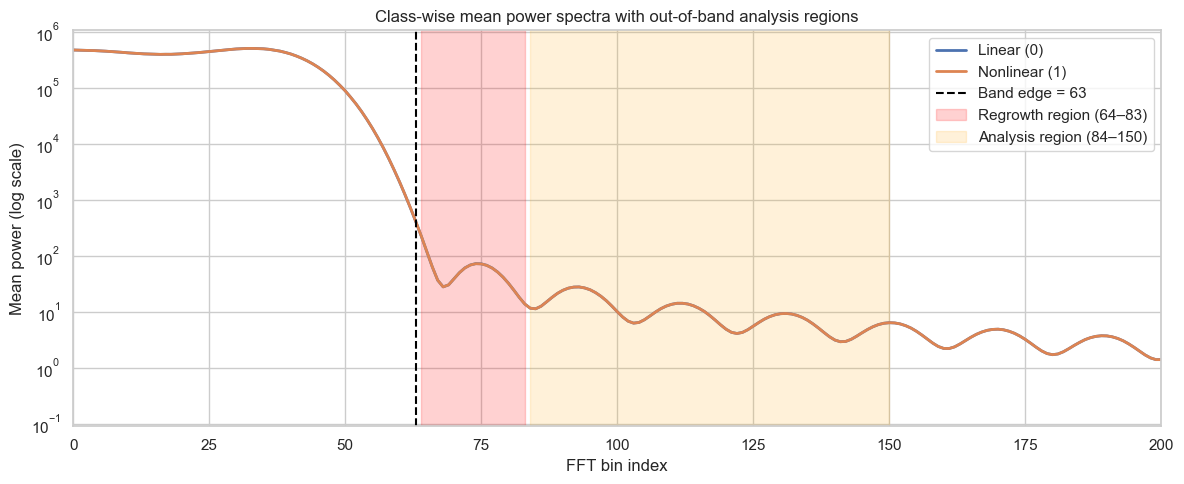

Validation complete: downstream ML will use only bins 64–150 (out-of-band).


In [18]:
# Section 1: Load and validate data

df = pd.read_csv(CSV_PATH)

expected_columns = N_BINS + 1
assert df.shape[1] == expected_columns, (
    f"Expected {expected_columns} columns (800 bins + label), found {df.shape[1]}."
)
assert LABEL_COL in df.columns, f"Missing label column: {LABEL_COL}"

# Select features strictly by position, never by column name
X_bins = df.iloc[:, :N_BINS].to_numpy(dtype=float)
y = df[LABEL_COL].to_numpy(dtype=int)

assert X_bins.shape[1] == N_BINS, "Feature extraction must include exactly 800 FFT bins."
assert np.isin(y, [0, 1]).all(), "Labels must be binary: 0 (linear), 1 (nonlinear)."

class_counts = pd.Series(y, name=LABEL_COL).value_counts().sort_index()
print("Class distribution (0=linear, 1=nonlinear):")
print(class_counts)
if set(class_counts.index.tolist()) == {0, 1}:
    print(f"Confirmed split -> linear: {class_counts.loc[0]}, nonlinear: {class_counts.loc[1]}")

# Mean spectrum per class
bins = np.arange(N_BINS)
mean_linear = X_bins[y == 0].mean(axis=0)
mean_nonlinear = X_bins[y == 1].mean(axis=0)

plt.figure(figsize=(12, 5))
plt.plot(bins, mean_linear, label="Linear (0)", linewidth=2)
plt.plot(bins, mean_nonlinear, label="Nonlinear (1)", linewidth=2)

plt.yscale("log")
plt.axvline(BAND_EDGE, color="black", linestyle="--", linewidth=1.5, label=f"Band edge = {BAND_EDGE}")
plt.axvspan(REGROWTH_START, REGROWTH_END, color="red", alpha=0.18, label="Regrowth region (64–83)")
plt.axvspan(REGROWTH_END + 1, ANALYSIS_END, color="orange", alpha=0.15, label="Analysis region (84–150)")

plt.xlim(0, 200)
plt.xlabel("FFT bin index")
plt.ylabel("Mean power (log scale)")
plt.title("Class-wise mean power spectra with out-of-band analysis regions")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

print("Validation complete: downstream ML will use only bins 64–150 (out-of-band).")

In [19]:
# Section 2: Compute engineered out-of-band features
assert REGROWTH_START > BAND_EDGE, "Regrowth start must be out-of-band."
assert MAIN_LOBE_END <= BAND_EDGE, "Main-lobe region must stay in-band."

analysis_slice = slice(REGROWTH_START, ANALYSIS_END + 1)
core_slice = slice(REGROWTH_START, REGROWTH_END + 1)
main_lobe_slice = slice(MAIN_LOBE_START, MAIN_LOBE_END + 1)

analysis_vals = X_bins[:, analysis_slice]
core_vals = X_bins[:, core_slice]
main_lobe_vals = X_bins[:, main_lobe_slice]
analysis_bin_idx = np.arange(REGROWTH_START, ANALYSIS_END + 1)

# 1) regrowth_power
regrowth_power = np.sum(core_vals, axis=1)

# 2) spectral_slope using polyfit on bins 64–150
spectral_slope = np.array([
    np.polyfit(analysis_bin_idx, row, 1)[0] for row in analysis_vals
])

# 3) spectral_entropy
analysis_sum = np.sum(analysis_vals, axis=1, keepdims=True) + 1e-10
p = analysis_vals / analysis_sum
spectral_entropy = -np.sum(p * np.log(p + 1e-10), axis=1)

# 4) spectral_flatness with numerically stable geometric mean
spectral_flatness = np.exp(np.mean(np.log(analysis_vals + 1e-10), axis=1)) / (
    np.mean(analysis_vals, axis=1) + 1e-10
)

# 5) acpr_db
adj_power = np.sum(core_vals, axis=1)
main_power = np.sum(main_lobe_vals, axis=1)
acpr_ratio = np.clip(adj_power / (main_power + 1e-10), 1e-10, None)
acpr_db = 10.0 * np.log10(acpr_ratio)

# 6) spectral_kurtosis
mean_analysis = np.mean(analysis_vals, axis=1, keepdims=True)
std_analysis = np.std(analysis_vals, axis=1, keepdims=True)
spectral_kurtosis = np.mean((analysis_vals - mean_analysis) ** 4, axis=1) / (
    (std_analysis.squeeze() ** 4) + 1e-10
)

features_df = pd.DataFrame({
    "regrowth_power": regrowth_power,
    "spectral_slope": spectral_slope,
    "spectral_entropy": spectral_entropy,
    "spectral_flatness": spectral_flatness,
    "acpr_db": acpr_db,
    "spectral_kurtosis": spectral_kurtosis,
})

print("Engineered feature matrix shape:", features_df.shape)
print("\nMean feature value by class (0=linear, 1=nonlinear):")
print(features_df.assign(nonlinear=y).groupby("nonlinear").mean())

print("\nCohen's d effect size by feature:")
cohens_d = {}
for feature in features_df.columns:
    g0 = features_df.loc[y == 0, feature].to_numpy()
    g1 = features_df.loc[y == 1, feature].to_numpy()
    mean_diff = np.abs(np.mean(g1) - np.mean(g0))
    pooled_std = np.sqrt((np.var(g0, ddof=1) + np.var(g1, ddof=1)) / 2.0) + 1e-10
    d = mean_diff / pooled_std
    cohens_d[feature] = d
    print(f"{feature:18s}: {d:.4f}")

cohens_d_series = pd.Series(cohens_d).sort_values(ascending=False)

Engineered feature matrix shape: (10000, 6)

Mean feature value by class (0=linear, 1=nonlinear):
           regrowth_power  spectral_slope  spectral_entropy  \
nonlinear                                                     
0             1174.779524       -0.756848          3.897742   
1             1174.520175       -0.756995          3.897030   

           spectral_flatness    acpr_db  spectral_kurtosis  
nonlinear                                                   
0                   0.594362 -41.902436          24.504303  
1                   0.594301 -41.902762          24.743475  

Cohen's d effect size by feature:
regrowth_power    : 0.0047
spectral_slope    : 0.0040
spectral_entropy  : 0.0226
spectral_flatness : 0.0038
acpr_db           : 0.0016
spectral_kurtosis : 0.0562


### 2.2 Distribution-Shape Motivation
Entropy, flatness, ACPR, and kurtosis describe complementary aspects of spectral texture: spread, tonality, adjacent-channel leakage relative to the main lobe, and peakiness. Together these features test whether weak nonlinear signatures are distributed across shape statistics rather than a single amplitude threshold.

## Section 3 — Feature Set Definitions
Four feature representations are created to separate the effect of raw regrowth bins from engineered domain features. This allows a controlled comparison of direct spectral learning versus hand-crafted summary statistics.

In [20]:
# Section 3: Build feature set dictionary
X_A = X_bins[:, REGROWTH_START:ANALYSIS_END + 1]           # 64–150 inclusive
X_B = features_df.to_numpy(dtype=float)                     # engineered only
X_C = np.hstack([X_A, X_B])                                 # raw + engineered
X_D = X_bins[:, REGROWTH_START:REGROWTH_END + 1]            # 64–83 inclusive

feature_sets = {
    "A: Raw Bins 64-150":  X_A,
    "B: Engineered Only":  X_B,
    "C: Raw + Engineered": X_C,
    "D: Core Bins 64-83":  X_D,
}

for name, X in feature_sets.items():
    print(f"{name:25s} -> {X.shape}")

A: Raw Bins 64-150        -> (10000, 87)
B: Engineered Only        -> (10000, 6)
C: Raw + Engineered       -> (10000, 93)
D: Core Bins 64-83        -> (10000, 20)


## Section 4 — Model Definitions
Each classifier is wrapped in a `Pipeline` with `StandardScaler` to ensure preprocessing is learned within each training fold only. This avoids information leakage and keeps model comparisons consistent across feature representations.

In [21]:
# Section 4: Define standardized model pipelines
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=4, random_state=RANDOM_STATE
        ))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=11))
    ]),
}

print("Models configured:")
for model_name in models:
    print(f"- {model_name}")

Models configured:
- Logistic Regression
- SVM
- Random Forest
- Gradient Boosting
- KNN


## Section 5 — Training and Evaluation
A stratified 5-fold cross-validation protocol is used for robust metric estimation on each model-feature combination. In parallel, a fixed stratified 80/20 split is stored per feature set to support ROC plotting and confusion matrix analysis on a consistent held-out partition.

In [22]:
# Section 5: Cross-validation and held-out split evaluation
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
results = []
split_artifacts = {}

for feature_set_name, X in feature_sets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )
    split_artifacts[feature_set_name] = {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "trained_models": {}
    }

    for model_name, model_pipeline in models.items():
        print(f"Training {model_name} on {feature_set_name}...")
        acc_scores, prec_scores, rec_scores, f1_scores, auc_scores = [], [], [], [], []
        opt_acc_scores, opt_prec_scores, opt_rec_scores, opt_f1_scores = [], [], [], []

        for train_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            fold_model = clone(model_pipeline)
            fold_model.fit(X_tr, y_tr)
            y_pred = fold_model.predict(X_val)

            if hasattr(fold_model, "predict_proba"):
                y_score = fold_model.predict_proba(X_val)[:, 1]
            elif hasattr(fold_model, "decision_function"):
                y_score = fold_model.decision_function(X_val)
            else:
                y_score = y_pred.astype(float)

            # find optimal threshold per fold using ROC curve
            fold_fpr, fold_tpr, fold_thresholds = roc_curve(y_val, y_score)
            fold_accuracies = []
            for t in fold_thresholds:
                fold_preds_t = (y_score >= t).astype(int)
                fold_accuracies.append(accuracy_score(y_val, fold_preds_t))
            best_t = fold_thresholds[np.argmax(fold_accuracies)]
            y_pred_optimal = (y_score >= best_t).astype(int)

            acc_scores.append(accuracy_score(y_val, y_pred))
            prec_scores.append(precision_score(y_val, y_pred, zero_division=0))
            rec_scores.append(recall_score(y_val, y_pred, zero_division=0))
            f1_scores.append(f1_score(y_val, y_pred, zero_division=0))
            auc_scores.append(roc_auc_score(y_val, y_score))

            opt_acc_scores.append(accuracy_score(y_val, y_pred_optimal))
            opt_prec_scores.append(precision_score(y_val, y_pred_optimal, zero_division=0))
            opt_rec_scores.append(recall_score(y_val, y_pred_optimal, zero_division=0))
            opt_f1_scores.append(f1_score(y_val, y_pred_optimal, zero_division=0))

        results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "accuracy_mean": np.mean(acc_scores),
            "accuracy_std": np.std(acc_scores),
            "precision_mean": np.mean(prec_scores),
            "precision_std": np.std(prec_scores),
            "recall_mean": np.mean(rec_scores),
            "recall_std": np.std(rec_scores),
            "f1_mean": np.mean(f1_scores),
            "f1_std": np.std(f1_scores),
            "auc_mean": np.mean(auc_scores),
            "auc_std": np.std(auc_scores),
            "opt_accuracy_mean": np.mean(opt_acc_scores),
            "opt_accuracy_std": np.std(opt_acc_scores),
            "opt_f1_mean": np.mean(opt_f1_scores),
            "opt_f1_std": np.std(opt_f1_scores),
        })

        holdout_model = clone(model_pipeline)
        holdout_model.fit(X_train, y_train)
        split_artifacts[feature_set_name]["trained_models"][model_name] = holdout_model

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("accuracy_mean", ascending=False).reset_index(drop=True)

print("\nCross-validation results (sorted by accuracy_mean):")
display(results_df)

Training Logistic Regression on A: Raw Bins 64-150...
Training SVM on A: Raw Bins 64-150...
Training Random Forest on A: Raw Bins 64-150...
Training Gradient Boosting on A: Raw Bins 64-150...
Training KNN on A: Raw Bins 64-150...
Training Logistic Regression on B: Engineered Only...
Training SVM on B: Engineered Only...
Training Random Forest on B: Engineered Only...
Training Gradient Boosting on B: Engineered Only...
Training KNN on B: Engineered Only...
Training Logistic Regression on C: Raw + Engineered...
Training SVM on C: Raw + Engineered...
Training Random Forest on C: Raw + Engineered...
Training Gradient Boosting on C: Raw + Engineered...
Training KNN on C: Raw + Engineered...
Training Logistic Regression on D: Core Bins 64-83...
Training SVM on D: Core Bins 64-83...
Training Random Forest on D: Core Bins 64-83...
Training Gradient Boosting on D: Core Bins 64-83...
Training KNN on D: Core Bins 64-83...

Cross-validation results (sorted by accuracy_mean):


,feature_set,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auc_mean,auc_std,opt_accuracy_mean,opt_accuracy_std,opt_f1_mean,opt_f1_std
0,B: Engineered Only,Logistic Regression,0.5157,0.013052,0.515850,0.012892,0.5134,0.017048,0.514525,0.013411,0.524247,0.013012,0.5255,0.006950,0.497559,0.073957
1,D: Core Bins 64-83,Logistic Regression,0.5116,0.009754,0.511689,0.010072,0.5130,0.013506,0.512242,0.009437,0.514059,0.009570,0.5196,0.006200,0.490177,0.134355
2,B: Engineered Only,SVM,0.4827,0.004389,0.482255,0.004820,0.4760,0.045743,0.478095,0.025055,0.521692,0.006047,0.5230,0.004301,0.536202,0.120632
3,C: Raw + Engineered,Logistic Regression,0.4779,0.005171,0.478059,0.005404,0.4826,0.017772,0.480194,0.010514,0.469849,0.008982,0.5027,0.001327,0.194892,0.247924
4,A: Raw Bins 64-150,Logistic Regression,0.4764,0.008083,0.476519,0.007977,0.4776,0.014094,0.476956,0.009036,0.470426,0.008401,0.5021,0.001594,0.197177,0.248868
5,B: Engineered Only,Gradient Boosting,0.4425,0.013657,0.440189,0.012763,0.4224,0.033272,0.430484,0.019989,0.414591,0.013050,0.5000,0.000000,0.000000,0.000000
6,D: Core Bins 64-83,Gradient Boosting,0.3887,0.005946,0.389856,0.005869,0.3944,0.019190,0.391948,0.011850,0.341949,0.010131,0.5000,0.000000,0.000000,0.000000
7,D: Core Bins 64-83,SVM,0.3466,0.003583,0.347956,0.009541,0.3526,0.027601,0.350021,0.018333,0.714538,0.003724,0.6580,0.004147,0.657920,0.019629
8,B: Engineered Only,KNN,0.3294,0.005481,0.330133,0.007122,0.3318,0.011565,0.330944,0.009199,0.289413,0.005356,0.5002,0.000400,0.000798,0.001597
9,D: Core Bins 64-83,KNN,0.3180,0.004550,0.320623,0.004399,0.3254,0.008868,0.322965,0.006251,0.280120,0.004340,0.5000,0.000000,0.000000,0.000000


In [23]:
# Section 5: Interpret aggregate performance against threshold baseline
baseline = 0.50
best_row = results_df.iloc[0]
best_feature_set = best_row["feature_set"]
best_model_name = best_row["model"]

avg_by_feature = results_df.groupby("feature_set", as_index=False)["accuracy_mean"].mean()
best_feature_group = avg_by_feature.sort_values("accuracy_mean", ascending=False).iloc[0]

engineered_acc = results_df.loc[results_df["feature_set"] == "B: Engineered Only", "accuracy_mean"].mean()
raw_acc = results_df.loc[results_df["feature_set"] == "A: Raw Bins 64-150", "accuracy_mean"].mean()
delta_eng_vs_raw = engineered_acc - raw_acc

print("Interpretation summary:")
print(f"- Best combination: {best_model_name} + {best_feature_set}")
print(f"- Best CV accuracy: {best_row['accuracy_mean']:.4f} ± {best_row['accuracy_std']:.4f}")
print(f"- Improvement over 0.50 threshold baseline: {best_row['accuracy_mean'] - baseline:+.4f}")
print(f"- Best feature set on average: {best_feature_group['feature_set']} ({best_feature_group['accuracy_mean']:.4f})")
print(f"- Mean engineered-only minus raw-bins accuracy: {delta_eng_vs_raw:+.4f}")

Interpretation summary:
- Best combination: Logistic Regression + B: Engineered Only
- Best CV accuracy: 0.5157 ± 0.0131
- Improvement over 0.50 threshold baseline: +0.0157
- Best feature set on average: B: Engineered Only (0.3750)
- Mean engineered-only minus raw-bins accuracy: +0.0815


The table and interpretation output above directly answer four key questions: whether ML meaningfully exceeds the 0.50 threshold baseline, which feature set is strongest, which model is strongest, and whether engineered features improve performance relative to raw regrowth bins alone. These points should be reported in the thesis appendix using the printed numerical values.

## Section 6 — Results Visualization
This section visualizes cross-validation outcomes in complementary formats: grouped bars for direct model comparisons and heatmaps for matrix-style trend inspection across feature sets and classifiers. Error bars represent one standard deviation across folds.

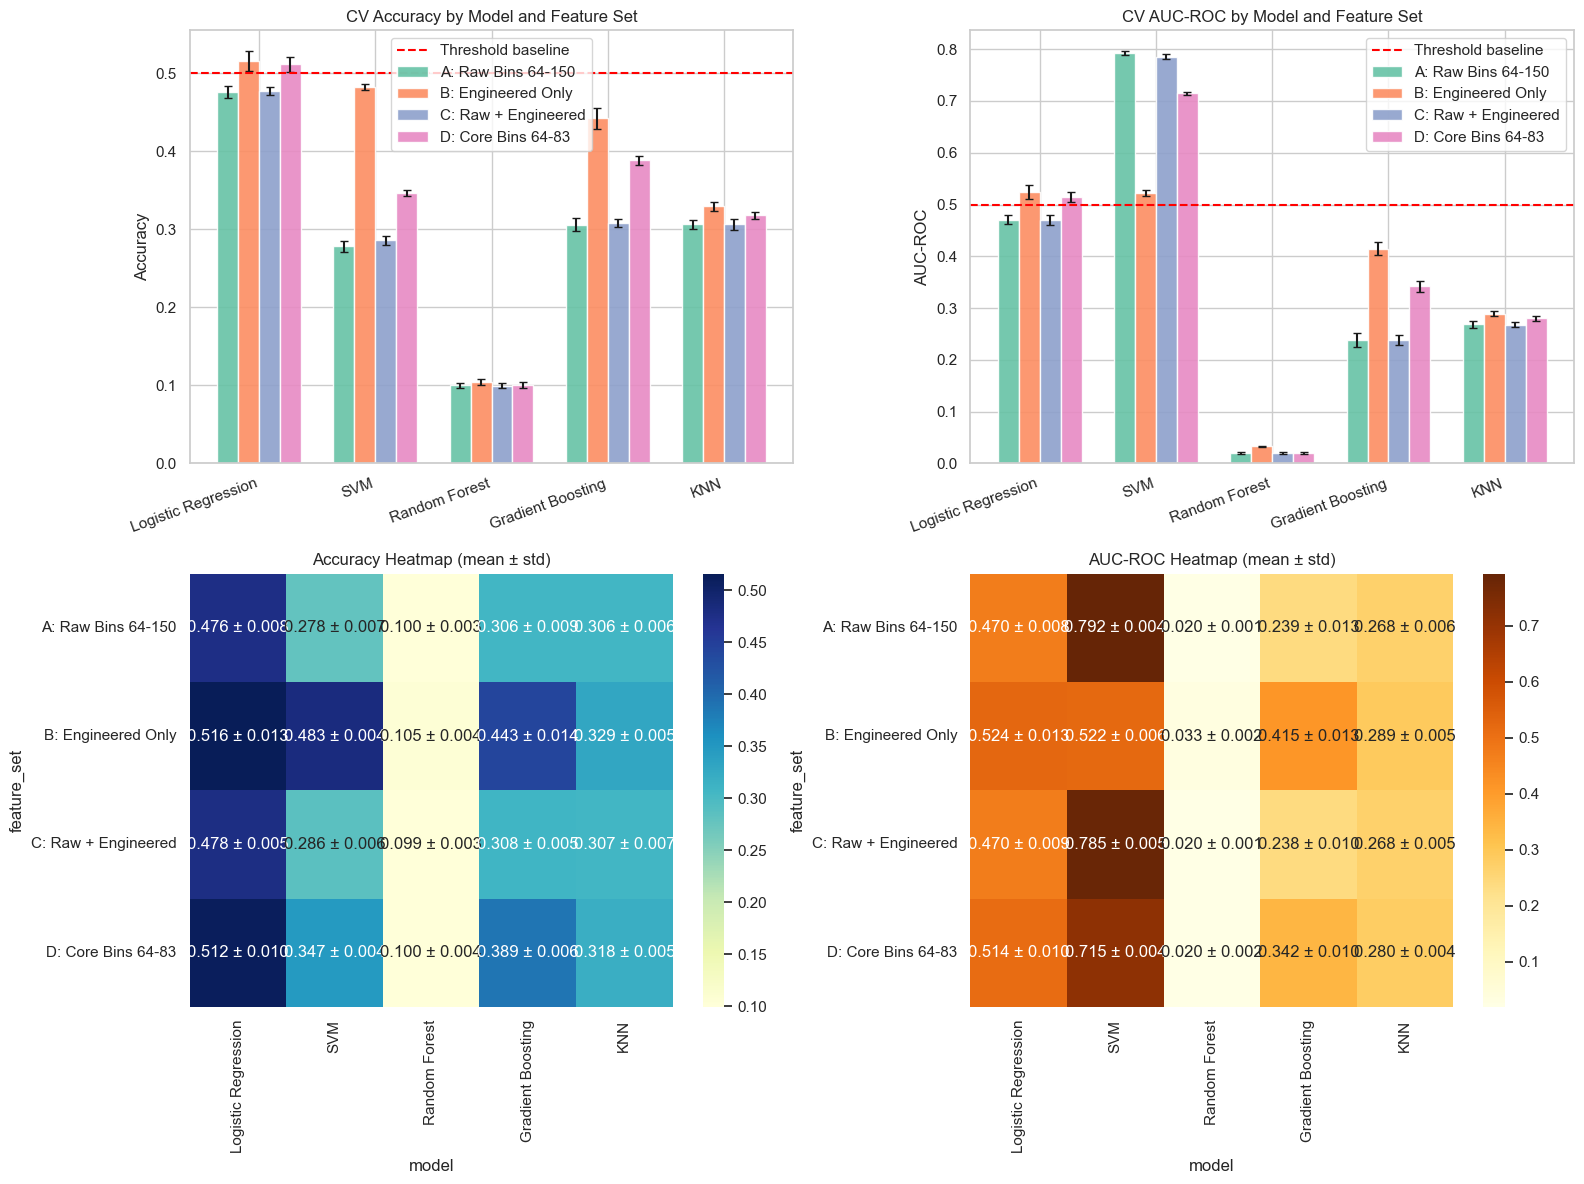

In [24]:
# Section 6: Plot CV accuracy/AUC grouped bars and heatmaps
model_order = list(models.keys())
feature_order = list(feature_sets.keys())

acc_mean = results_df.pivot(index="model", columns="feature_set", values="accuracy_mean").loc[model_order, feature_order]
acc_std = results_df.pivot(index="model", columns="feature_set", values="accuracy_std").loc[model_order, feature_order]
auc_mean = results_df.pivot(index="model", columns="feature_set", values="auc_mean").loc[model_order, feature_order]
auc_std = results_df.pivot(index="model", columns="feature_set", values="auc_std").loc[model_order, feature_order]

x = np.arange(len(model_order))
width = 0.18
offsets = np.linspace(-1.5 * width, 1.5 * width, len(feature_order))
palette = sns.color_palette("Set2", n_colors=len(feature_order))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accuracy grouped bars
ax = axes[0, 0]
for i, fs_name in enumerate(feature_order):
    ax.bar(
        x + offsets[i],
        acc_mean[fs_name].values,
        width=width,
        yerr=acc_std[fs_name].values,
        capsize=3,
        label=fs_name,
        color=palette[i],
        alpha=0.9
    )
ax.axhline(0.50, color="red", linestyle="--", linewidth=1.5, label="Threshold baseline")
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=20, ha='right')
ax.set_ylabel("Accuracy")
ax.set_title("CV Accuracy by Model and Feature Set")
ax.legend(loc="best")

# Plot 2: AUC grouped bars
ax = axes[0, 1]
for i, fs_name in enumerate(feature_order):
    ax.bar(
        x + offsets[i],
        auc_mean[fs_name].values,
        width=width,
        yerr=auc_std[fs_name].values,
        capsize=3,
        label=fs_name,
        color=palette[i],
        alpha=0.9
    )
ax.axhline(0.50, color="red", linestyle="--", linewidth=1.5, label="Threshold baseline")
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=20, ha='right')
ax.set_ylabel("AUC-ROC")
ax.set_title("CV AUC-ROC by Model and Feature Set")
ax.legend(loc="best")

# Plot 3: Accuracy heatmap with mean ± std
ax = axes[1, 0]
acc_heat = results_df.pivot(index="feature_set", columns="model", values="accuracy_mean").loc[feature_order, model_order]
acc_std_heat = results_df.pivot(index="feature_set", columns="model", values="accuracy_std").loc[feature_order, model_order]
acc_annot = acc_heat.copy().astype(str)
for r in acc_heat.index:
    for c in acc_heat.columns:
        acc_annot.loc[r, c] = f"{acc_heat.loc[r, c]:.3f} ± {acc_std_heat.loc[r, c]:.3f}"
sns.heatmap(
    acc_heat, annot=acc_annot.values, fmt="", cmap="YlGnBu", cbar=True, ax=ax
 )
ax.set_title("Accuracy Heatmap (mean ± std)")

# Plot 4: AUC heatmap with mean ± std
ax = axes[1, 1]
auc_heat = results_df.pivot(index="feature_set", columns="model", values="auc_mean").loc[feature_order, model_order]
auc_std_heat = results_df.pivot(index="feature_set", columns="model", values="auc_std").loc[feature_order, model_order]
auc_annot = auc_heat.copy().astype(str)
for r in auc_heat.index:
    for c in auc_heat.columns:
        auc_annot.loc[r, c] = f"{auc_heat.loc[r, c]:.3f} ± {auc_std_heat.loc[r, c]:.3f}"
sns.heatmap(
    auc_heat, annot=auc_annot.values, fmt="", cmap="YlOrBr", cbar=True, ax=ax
 )
ax.set_title("AUC-ROC Heatmap (mean ± std)")

plt.tight_layout()
plt.show()

## Section 7 — ROC Curves
ROC analysis on a fixed held-out split highlights ranking performance and threshold-independent separability. Each subplot corresponds to one feature set and overlays all five models, enabling direct within-representation comparison.

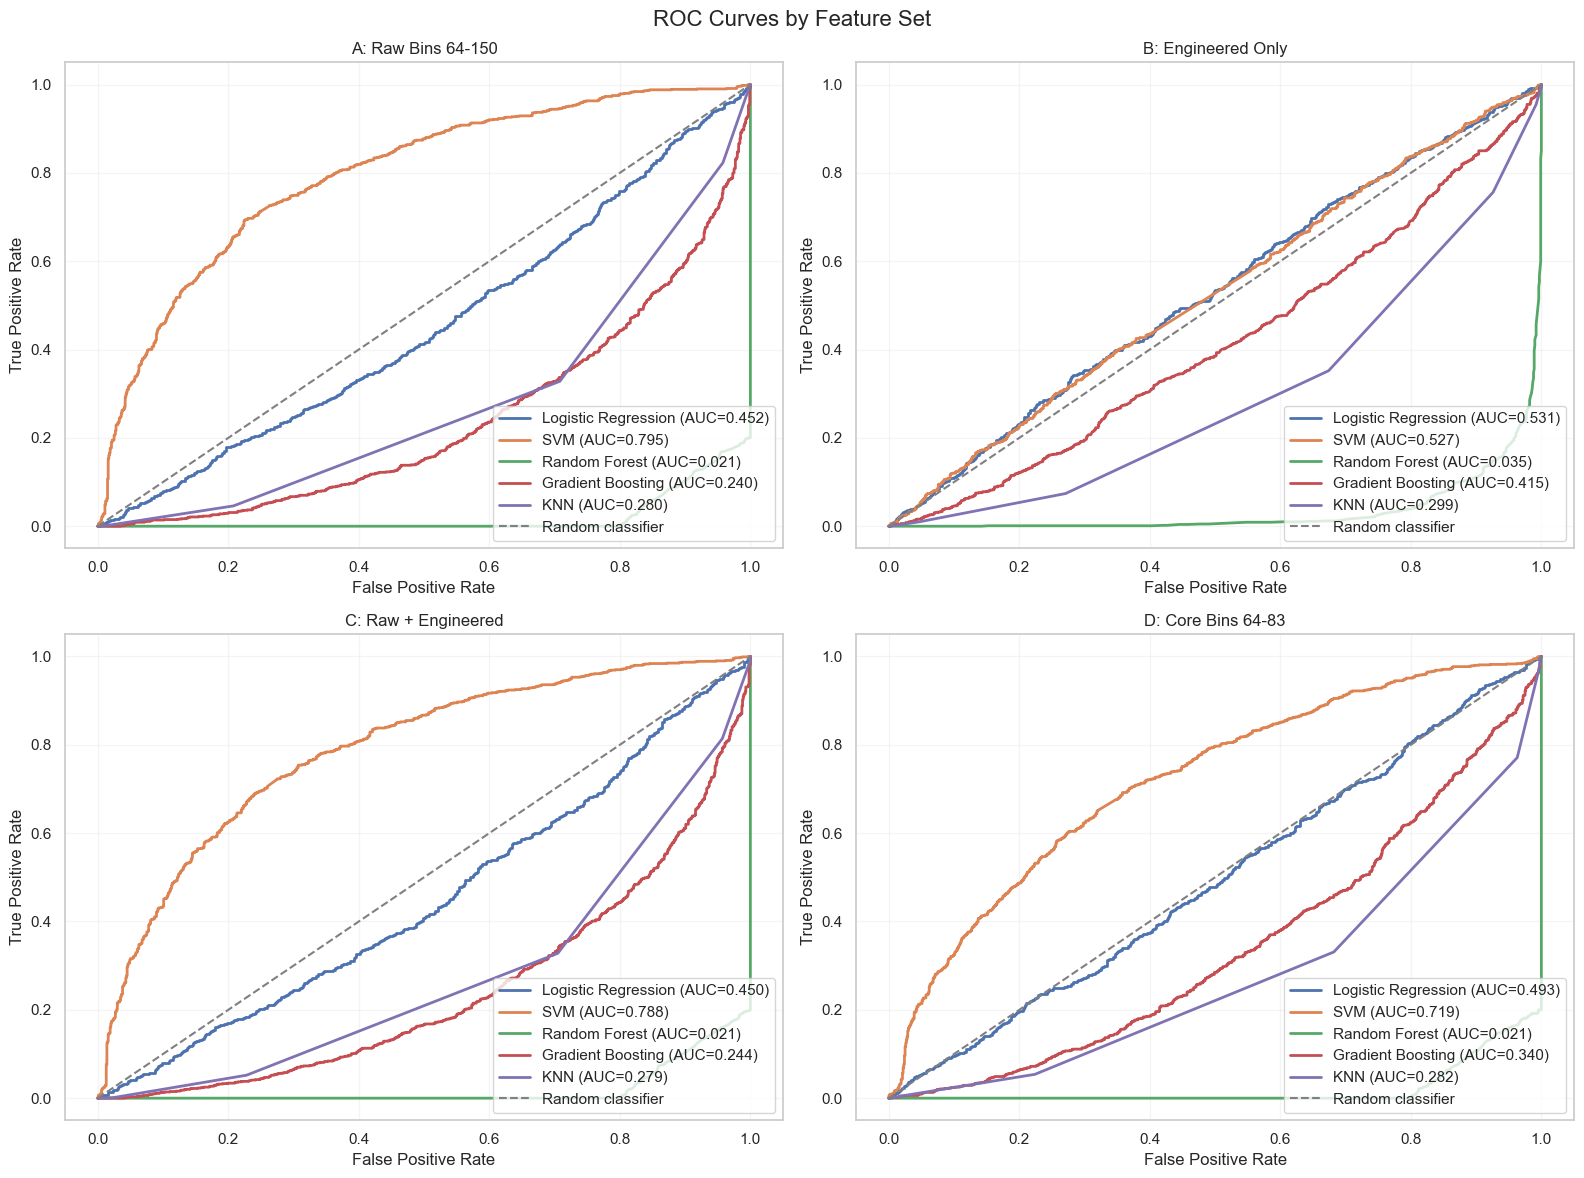

In [25]:
# Section 7: Plot ROC curves by feature set on held-out splits
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, feature_set_name in zip(axes, feature_order):
    artifact = split_artifacts[feature_set_name]
    X_test = artifact["X_test"]
    y_test = artifact["y_test"]

    for model_name in model_order:
        fitted_model = artifact["trained_models"][model_name]
        if hasattr(fitted_model, "predict_proba"):
            y_score = fitted_model.predict_proba(X_test)[:, 1]
        elif hasattr(fitted_model, "decision_function"):
            raw_score = fitted_model.decision_function(X_test)
            y_score = (raw_score - raw_score.min()) / (raw_score.max() - raw_score.min() + 1e-10)
        else:
            y_score = fitted_model.predict(X_test).astype(float)

        fpr, tpr, _ = roc_curve(y_test, y_score)
        auc_val = roc_auc_score(y_test, y_score)
        ax.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC={auc_val:.3f})")

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5, label='Random classifier')
    ax.set_title(feature_set_name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(alpha=0.2)
    ax.legend(loc="lower right")

fig.suptitle("ROC Curves by Feature Set", fontsize=16)
plt.tight_layout()
plt.show()

## Section 8 — Feature Importance Analysis
Random Forest importances are used as a model-agnostic proxy for discriminative contribution under nonlinear interactions. We inspect both raw out-of-band bins (64–150) and engineered descriptors to determine whether learned relevance aligns with expected regrowth physics near the band edge.

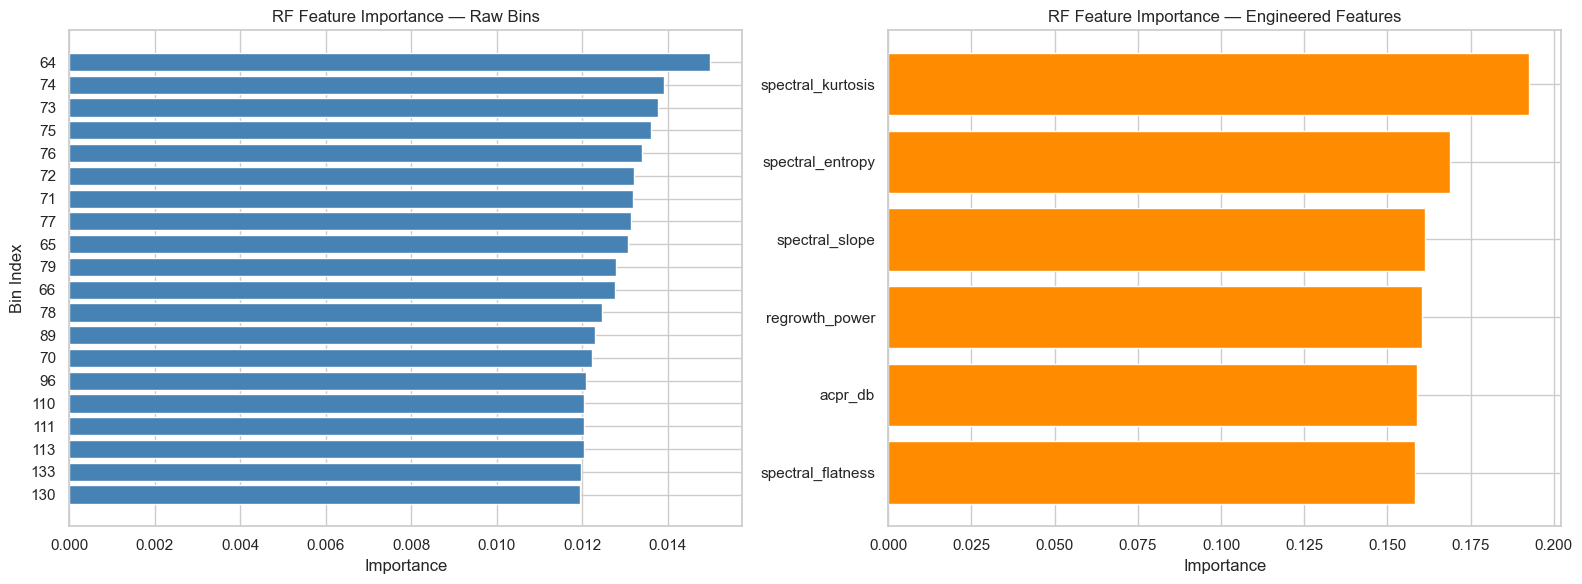

In [26]:
# Section 8: Random Forest feature-importance analysis
rf_raw = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
])
rf_eng = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
])

X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(
    X_A, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

rf_raw.fit(X_A_train, y_A_train)
rf_eng.fit(X_B_train, y_B_train)

importances_raw = rf_raw.named_steps["model"].feature_importances_
importances_eng = rf_eng.named_steps["model"].feature_importances_
raw_bin_indices = np.arange(REGROWTH_START, ANALYSIS_END + 1)

top_k = 20
top_idx = np.argsort(importances_raw)[-top_k:][::-1]
top_bins = raw_bin_indices[top_idx]
top_imps = importances_raw[top_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Raw bins top-20
axes[0].barh(np.arange(top_k), top_imps[::-1], color="steelblue")
axes[0].set_yticks(np.arange(top_k))
axes[0].set_yticklabels(top_bins[::-1])
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Bin Index")
axes[0].set_title("RF Feature Importance — Raw Bins")

# Right: Engineered features (all 6)
eng_names = features_df.columns.to_list()
order_eng = np.argsort(importances_eng)
axes[1].barh(np.arange(len(eng_names)), importances_eng[order_eng], color="darkorange")
axes[1].set_yticks(np.arange(len(eng_names)))
axes[1].set_yticklabels(np.array(eng_names)[order_eng])
axes[1].set_xlabel("Importance")
axes[1].set_title("RF Feature Importance — Engineered Features")

plt.tight_layout()
plt.show()

The importance profiles indicate which portions of the regrowth skirt and which engineered descriptors carry class-discriminative information. If high-ranked raw bins cluster near 64–83 and ACPR or slope-based features rank strongly, this aligns with the physical expectation that weak nonlinear separability is concentrated just beyond the band edge rather than inside the main lobe.

## Section 9 — Confusion Matrices
The confusion matrix is plotted for the single best-performing model-feature combination selected by cross-validated mean accuracy. Both raw counts and row-normalized percentages are shown to expose class-specific error asymmetry.

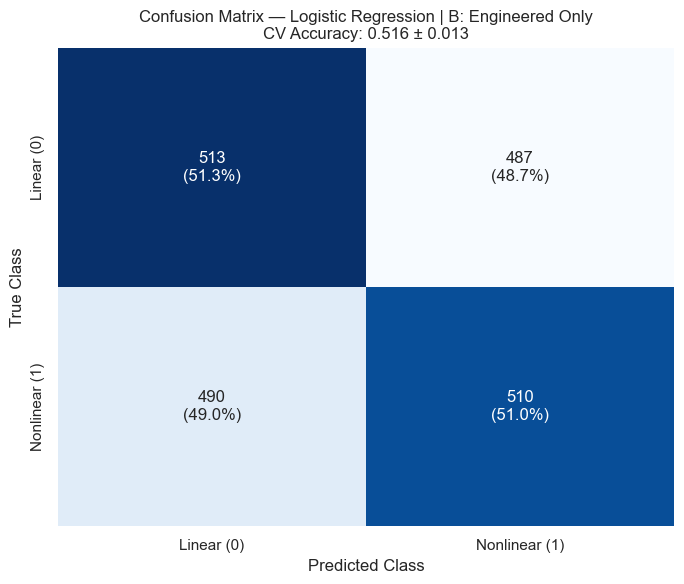

In [27]:
# Section 9: Confusion matrix for best CV model-feature combination
best_row = results_df.iloc[0]
best_feature_set = best_row["feature_set"]
best_model_name = best_row["model"]
best_model = split_artifacts[best_feature_set]["trained_models"][best_model_name]

X_test_best = split_artifacts[best_feature_set]["X_test"]
y_test_best = split_artifacts[best_feature_set]["y_test"]
y_pred_best = best_model.predict(X_test_best)

cm = confusion_matrix(y_test_best, y_pred_best)
cm_row_pct = cm / (cm.sum(axis=1, keepdims=True) + 1e-10)

annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({100 * cm_row_pct[i, j]:.1f}%)"

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=annot, fmt="", cmap="Blues", cbar=False,
    xticklabels=["Linear (0)", "Nonlinear (1)"],
    yticklabels=["Linear (0)", "Nonlinear (1)"]
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(
    f"Confusion Matrix — {best_model_name} | {best_feature_set}\n"
    f"CV Accuracy: {best_row['accuracy_mean']:.3f} ± {best_row['accuracy_std']:.3f}"
)
plt.tight_layout()
plt.show()

### Final Summary
This pipeline directly tests whether traditional ML can beat the failed power-threshold baseline in the constrained out-of-band setting. If the top cross-validated accuracy is materially above 0.50, then distributed regrowth-shape information is present and learnable; if gains remain marginal, it supports moving to richer nonlinear representations. The relative performance of Feature Sets A–D indicates whether discriminative content is concentrated in the 64–83 core, spread across 64–150, or better captured by engineered descriptors. These outcomes motivate the next phase: evaluating DNN models that can learn subtle higher-order spectral structure beyond manually designed statistics.